# Nacitanie dat

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import matplotlib.ticker as ticker

In [2]:
donations = pd.read_csv("data_sources/donations.csv")
print(f"sucet prispevkov: {sum(donations['amount'])} €\n")
print(donations["amount"].describe())
print(donations["amount"].median())
donations["sex"] = donations["sex"].replace({None:"firma"})


sucet prispevkov: 73821898.78 €

count    2.219800e+04
mean     3.325610e+03
std      3.265485e+04
min      0.000000e+00
25%      2.000000e+01
50%      6.639000e+01
75%      6.000000e+02
max      2.000000e+06
Name: amount, dtype: float64
66.39


# Vizualizacie

## typ vs celkova suma

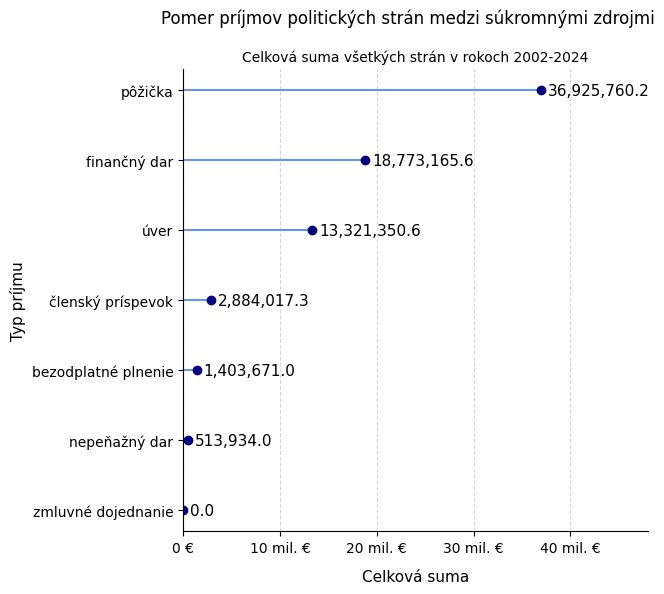

In [3]:
df = donations.groupby(["income_type"])["amount"].sum()
ordered_df = df.sort_values(ascending=True).reset_index()
fig, ax = plt.subplots(figsize=(6, 6))

my_range = range(1, len(ordered_df) + 1) 
plt.hlines(y=my_range, xmin=0, xmax=ordered_df['amount'], color='cornflowerblue')
plt.plot(ordered_df['amount'], my_range, "o",color="navy")
plt.yticks(my_range, ordered_df["income_type"])

x_offset =ordered_df["amount"].max() * 0.02
for i in range(len(my_range)):
    offseted = ordered_df["amount"][i] + x_offset
    plt.text(
        x=offseted, 
        y=my_range[i],
        s=f"{round(ordered_df['amount'][i],1):,}",
        va="center", 
        size=11
    )

plt.xlim(0, ordered_df["amount"].max() * 1.3)


# # Remove the unnecessary box borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.grid(axis="y", visible=False)
plt.gca().set_axisbelow(True)  # Keeps grid lines behind your bars/dots

def million_formatter(x, pos):
    return f"{x*1e-6:.0f} mil. €" if x != 0 else "0 €"
def million_formatter2(x, pos):
    return f"{x*1e-6:.1f} mil. €" if x != 0 else "0 €"
# def hundred_thousands_formatter(x,pos):
#     return f"{x*1e-4:.0f} tis. €" if x!=0 else "0"

plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(million_formatter))
plt.xlabel("Celková suma", fontsize=11, labelpad=10)
plt.ylabel("Typ príjmu",fontsize=11)
plt.title("Celková suma všetkých strán v rokoch 2002-2024",fontsize=10)

plt.suptitle("Pomer príjmov politických strán medzi súkromnými zdrojmi")
image_folder = "image_exports/"
plt.savefig(image_folder + "suma_podla_prijmu.pdf",bbox_inches='tight')
plt.show()

## boxplot podla typu 

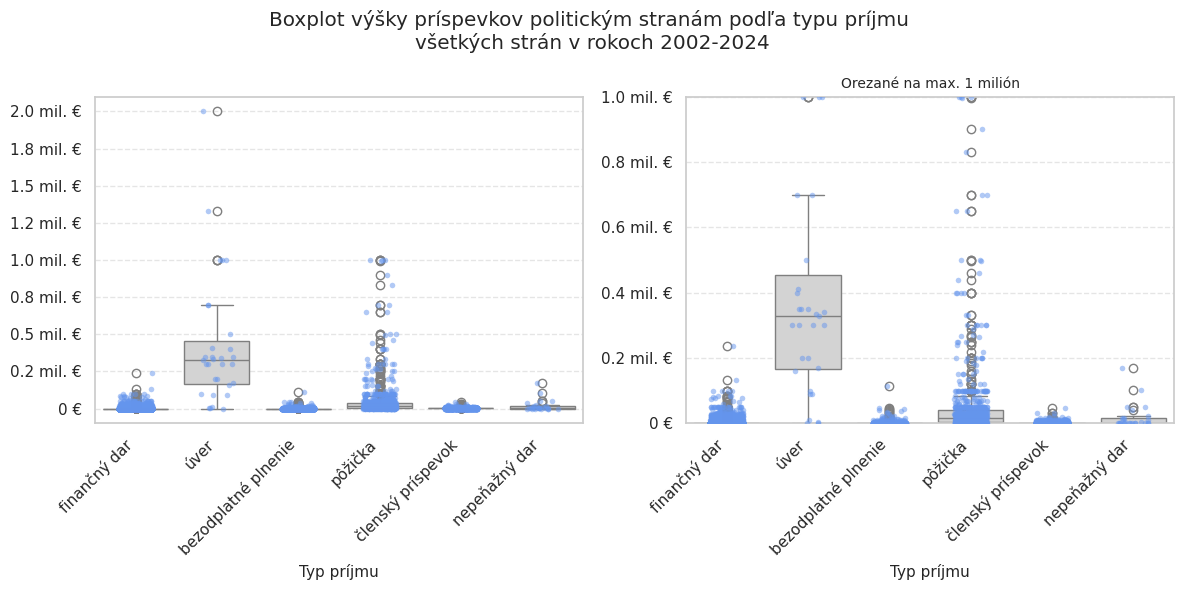

In [4]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
df = donations.loc[donations["income_type"]!="zmluvné dojednanie"].copy()
df['date'] = pd.to_datetime(df['date'],format='mixed')
df["year"] = df["date"].dt.year 

fig.suptitle("Boxplot výšky príspevkov politickým stranám podľa typu príjmu \nvšetkých strán v rokoch 2002-2024")

sns.boxplot(data=df, x="income_type", y="amount", width=.8, color="lightgray", ax=axes[0])
sns.stripplot(data=df, x="income_type", y="amount", size=4, jitter=0.2, alpha=0.5, color="cornflowerblue", ax=axes[0])
# axes[0].set_title(, fontsize=10)


sns.boxplot(data=df, x="income_type", y="amount", width=.8, color="lightgray", ax=axes[1])
sns.stripplot(data=df, x="income_type", y="amount", size=4, jitter=0.2, alpha=0.5, color="cornflowerblue", ax=axes[1])
axes[1].set_ylim(0, 1e6)
axes[1].set_title("Orezané na max. 1 milión", fontsize=10)
for ax in axes:
    ax.set_ylabel("", fontsize=11)
    ax.set_xlabel("Typ príjmu", fontsize=11)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)
    
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(million_formatter2))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()


plt.savefig(image_folder + "boxplot_podla_prijmu_porovnanie.pdf", bbox_inches='tight')
plt.show()







## histogram

In [5]:
list_donations = ['finančný dar', 'nepeňažný dar', 'bezodplatné plnenie','členský príspevok']
list_credits = ['úver', 'pôžička']

donations_only = donations[donations["income_type"].isin(list_donations)]
credits = donations[donations["income_type"].isin(list_credits)]

df["category"] = ["donation" if x in list_donations else "credit" for x in df["income_type"]]


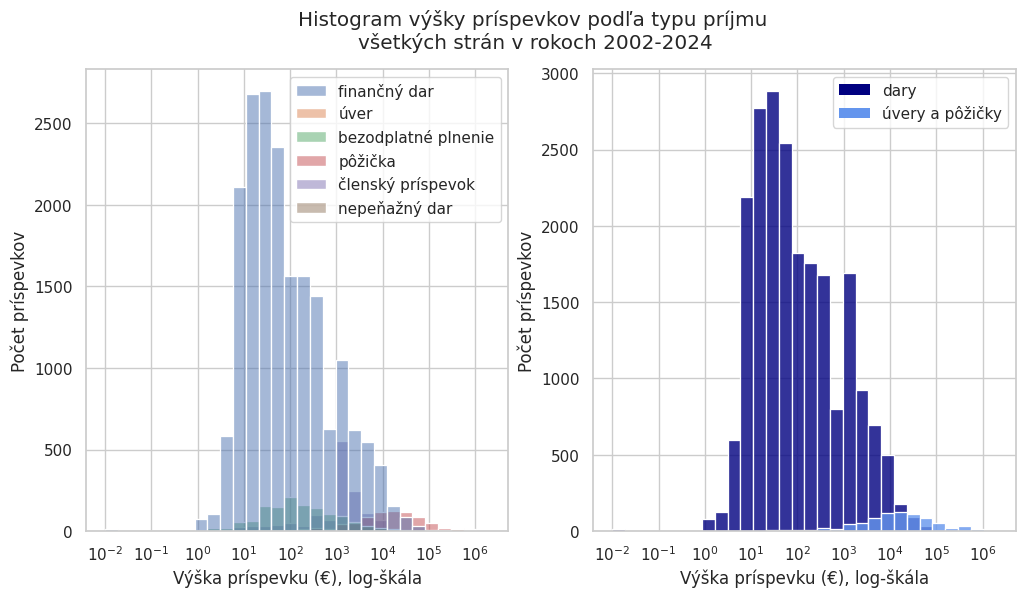

In [6]:
fig,ax = plt.subplots(1,2,figsize=(12,6))
my_palette = ["cornflowerblue","navy"]

sns.histplot(data=df,x="amount",hue="income_type",log_scale=True,common_norm=False,ax=ax[0],bins=30,legend=True)
ax[0].legend_.set_title("")

sns.histplot(data=df,x="amount",hue="category",hue_order=["credit","donation"],log_scale=True,common_norm=False,ax=ax[1],palette=my_palette,alpha=0.8,bins=30,legend=False)

def legend_twocolors(pos):
    topbar = plt.Rectangle((0,0),1,1,fc="navy", edgecolor = 'none')
    bottombar = plt.Rectangle((0,0),1,1,fc='cornflowerblue',  edgecolor = 'none')
    l = plt.legend([topbar,bottombar], ['dary','úvery a pôžičky'], loc=pos, ncol = 1, prop={'size':11})
    l.draw_frame(True) 
legend_twocolors(1)
plt.suptitle("Histogram výšky príspevkov podľa typu príjmu \nvšetkých strán v rokoch 2002-2024")
# plt.title("Všetkých strán v rokoch 2002-2024",fontsize=10) 
for i in range(2):
    ax[i].set_xlabel("Výška príspevku (€), log-škála")
    ax[i].set_ylabel("Počet príspevkov") 
plt.savefig(image_folder + "histogram_prispevky.pdf",bbox_inches='tight')
# print(df.sort_values("amount",ascending=True).head())

## Rebricek

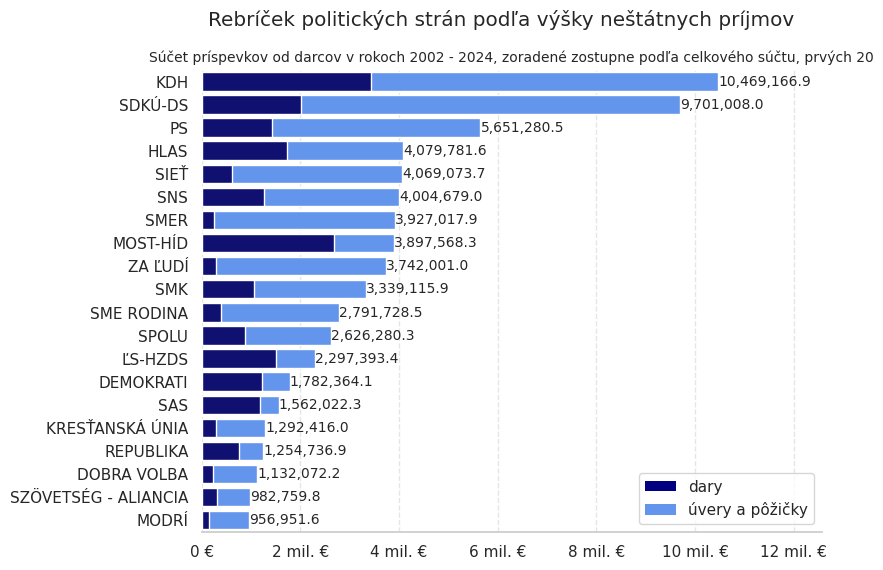

In [7]:
df1 = donations.groupby("party")["amount"].sum().reset_index().sort_values("amount",ascending=False).head(20)
# print(df1)
ordering =list(df1["party"])

df2 = donations_only.groupby("party")["amount"].sum().reset_index().sort_values("amount",ascending=False)

fig,ax = plt.subplots(figsize=(8,6))
bar1 = sns.barplot(data=df1,x="amount",y="party",color="cornflowerblue",saturation=1)
ax.bar_label(ax.containers[0],fontsize=10,fmt="{:,.1f}")
#total suma ukazuje napravo..
bar2 = sns.barplot(data=df2,x="amount",y="party",order=ordering,color="navy")
# ax.bar_label(ax.containers[1],fontsize=10,label_type="center",color="white")


legend_twocolors(4)


sns.despine(left=True)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.gca().set_axisbelow(True)
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(million_formatter))

plt.xlim(0, df1["amount"].max() * 1.2)
plt.xlabel("")
plt.ylabel("",)
plt.suptitle("Rebríček politických strán podľa výšky neštátnych príjmov")
plt.title("Súčet príspevkov od darcov v rokoch 2002 - 2024, zoradené zostupne podľa celkového súčtu, prvých 20",fontsize=10)
plt.savefig(image_folder + "rebricek_vyska.pdf",bbox_inches='tight')

pass


## pocet unikatnych darcov

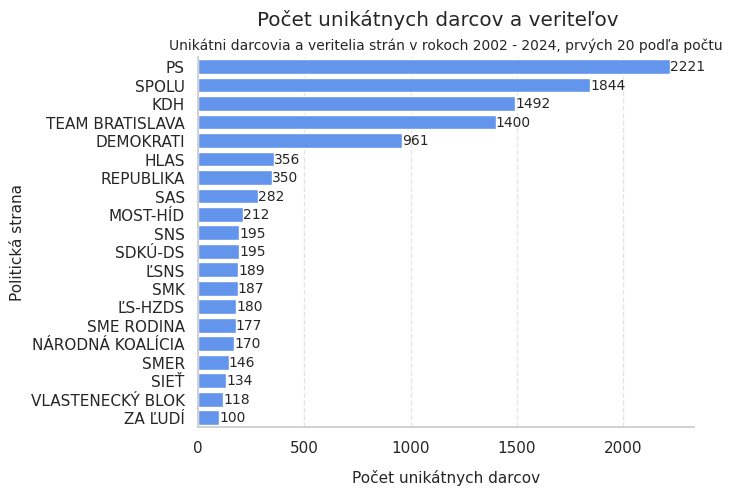

In [8]:
df_cleared = df.drop_duplicates(subset=["party_id", "user_id"], keep="first",inplace=False)
df1 = df_cleared.groupby("party")["user_id"].nunique().reset_index(name="unique").sort_values("unique",ascending=False).head(20)
ax = sns.barplot(data=df1,x="unique",y="party",color="cornflowerblue",saturation=1)
ax.bar_label(ax.containers[0],fontsize=10)
sns.set_context({"figure.figsize": (8, 6)})
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.gca().set_axisbelow(True)
sns.despine()
plt.suptitle("Počet unikátnych darcov a veriteľov")
plt.title("Unikátni darcovia a veritelia strán v rokoch 2002 - 2024, prvých 20 podľa počtu",fontsize=10)
plt.xlabel("Počet unikátnych darcov", fontsize=11, labelpad=10)
plt.ylabel("Politická strana", fontsize=11)
plt.savefig(image_folder + "pocet_unikatnych.pdf",bbox_inches='tight')

pass

## vysky darov podla krajov

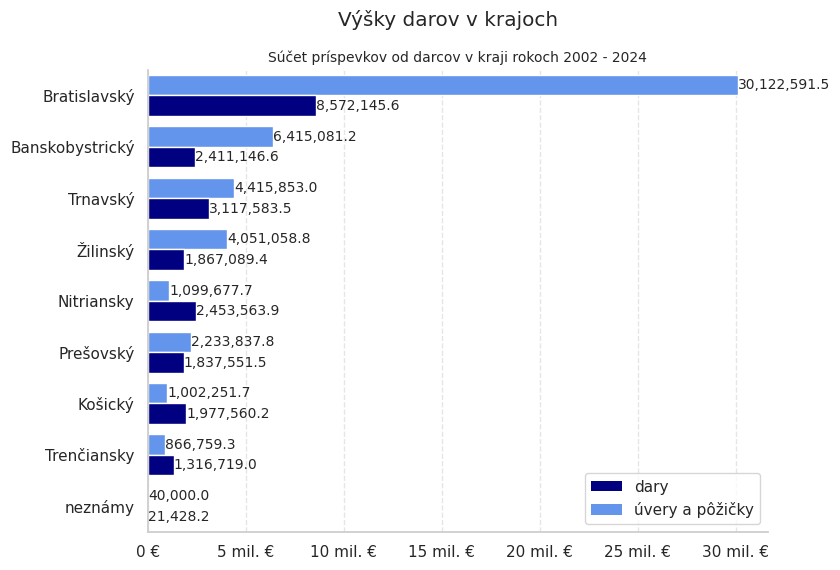

In [9]:
df1 = df.groupby(["region","category"])["amount"].sum().reset_index().sort_values("amount",ascending=False)
fig,ax = plt.subplots(figsize=(8,6))
sns.barplot(data=df1,x="amount",y="region",hue="category",palette = my_palette,saturation=1,legend=False)
ax.bar_label(ax.containers[0],fontsize=10,fmt="{:,.1f}")
ax.bar_label(ax.containers[1],fontsize=10,fmt="{:,.1f}")
sns.despine()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.gca().set_axisbelow(True)
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(million_formatter))
plt.suptitle("Výšky darov v krajoch")
plt.title("Súčet príspevkov od darcov v kraji rokoch 2002 - 2024",fontsize=10)
plt.ylabel("")
plt.xlabel("")


legend_twocolors(4)
plt.savefig(image_folder + "vyska_kraje.pdf",bbox_inches='tight')


## unikatni darcovia v krajoch

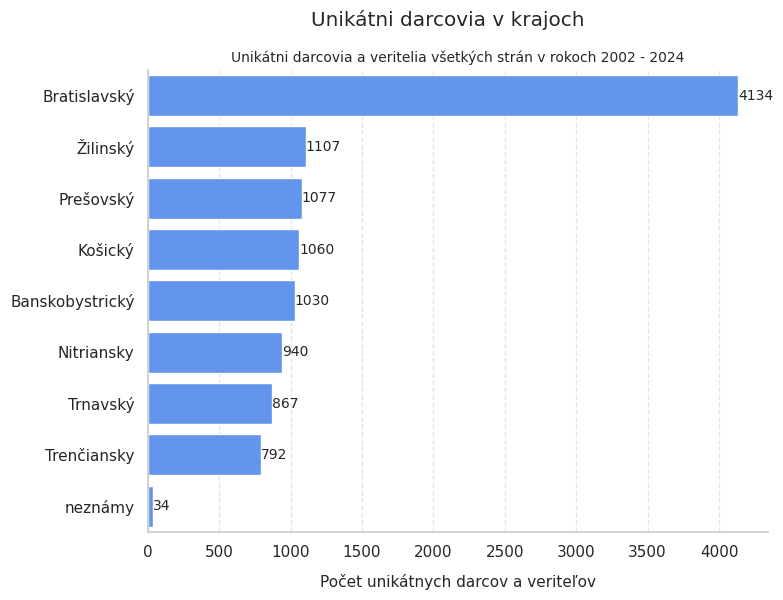

In [10]:
df_cleared = df.drop_duplicates(subset=["user_id"], keep="first",inplace=False)
df1 = df_cleared.groupby("region")["user_id"].size().reset_index(name="unique").sort_values("unique",ascending=False)

# print(sum(df1["unique"]))
fig,ax = plt.subplots(figsize=(8,6))
sns.barplot(data=df1,x="unique",y="region",color="cornflowerblue",saturation=1)
ax.bar_label(ax.containers[0],fontsize=10)
sns.despine()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.gca().set_axisbelow(True)
plt.xlabel("Počet unikátnych darcov a veriteľov", fontsize=11, labelpad=10)
plt.suptitle("Unikátni darcovia v krajoch")
plt.title("Unikátni darcovia a veritelia všetkých strán v rokoch 2002 - 2024",fontsize=10)
plt.ylabel("")
plt.savefig(image_folder + "unikatni_kraje.pdf",bbox_inches='tight')

pass


## vysky darov podla pohlavia

/tmp/ipykernel_11459/1668333980.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(xticklabels=["firma", "muži", "ženy"])


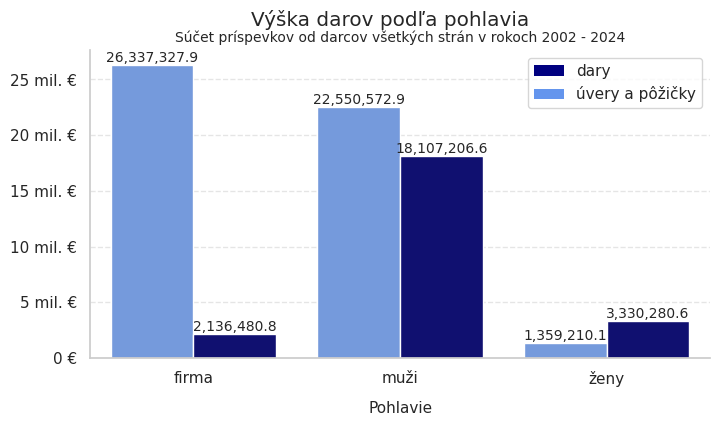

In [11]:
df1 = df.groupby(["sex","category"], dropna=False)["amount"].sum().reset_index().sort_values("amount",ascending=False)
# print(df1)
fig,ax = plt.subplots(figsize=(8,4))
sns.barplot(data=df1,x="sex",y="amount",hue="category",palette=my_palette,order=["firma","M","F"])
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(million_formatter))
ax.set(xticklabels=["firma", "muži", "ženy"])
ax.bar_label(ax.containers[0],fontsize=10,fmt="{:,.1f}")
ax.bar_label(ax.containers[1],fontsize=10,fmt="{:,.1f}")
plt.suptitle("Výška darov podľa pohlavia")
plt.title("Súčet príspevkov od darcov všetkých strán v rokoch 2002 - 2024",fontsize=10)

legend_twocolors(1)

sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.gca().set_axisbelow(True)
plt.xlabel("Pohlavie", fontsize=11, labelpad=10)
plt.ylabel("")
plt.savefig(image_folder + "vyska_pohlavie.pdf",bbox_inches='tight')

pass

## pocet darcov podla pohlavia

11041


/tmp/ipykernel_11459/1313181230.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(xticklabels=["muži", "ženy","firma"])


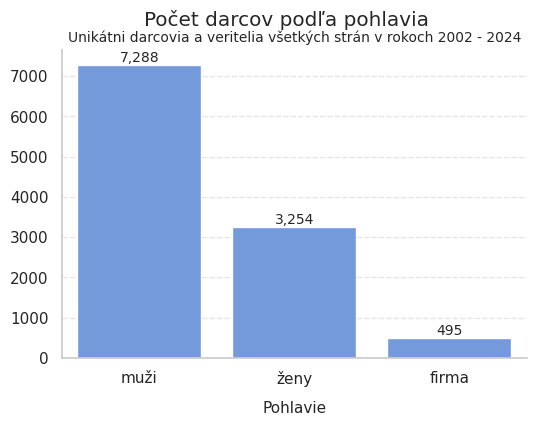

In [12]:
df_cleared = df.drop_duplicates(subset=["user_id"], keep="first",inplace=False)
df1 = df_cleared.groupby("sex")["user_id"].count().reset_index(name="count").sort_values("count",ascending=False)
print(sum(df1["count"]))
# mne vychadza 11047 ako aj by clovek cakal
# im vychadza 10660

# print(df1)
fig,ax = plt.subplots(figsize=(6,4))
sns.barplot(data=df1,x="sex",y="count",order=["M","F","firma"],color="cornflowerblue")
plt.suptitle("Počet darcov podľa pohlavia")
plt.title("Unikátni darcovia a veritelia všetkých strán v rokoch 2002 - 2024",fontsize=10)
ax.set(xticklabels=["muži", "ženy","firma"])
ax.bar_label(ax.containers[0],fontsize=10,fmt="{:,.0f}")
sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.gca().set_axisbelow(True)
plt.xlabel("Pohlavie", fontsize=11, labelpad=10)
plt.ylabel("")
plt.savefig(image_folder + "pocet_pohlavie.pdf",bbox_inches='tight')
pass

## analyza datumov a maximalnej vysky (IBA DONATIONS!)

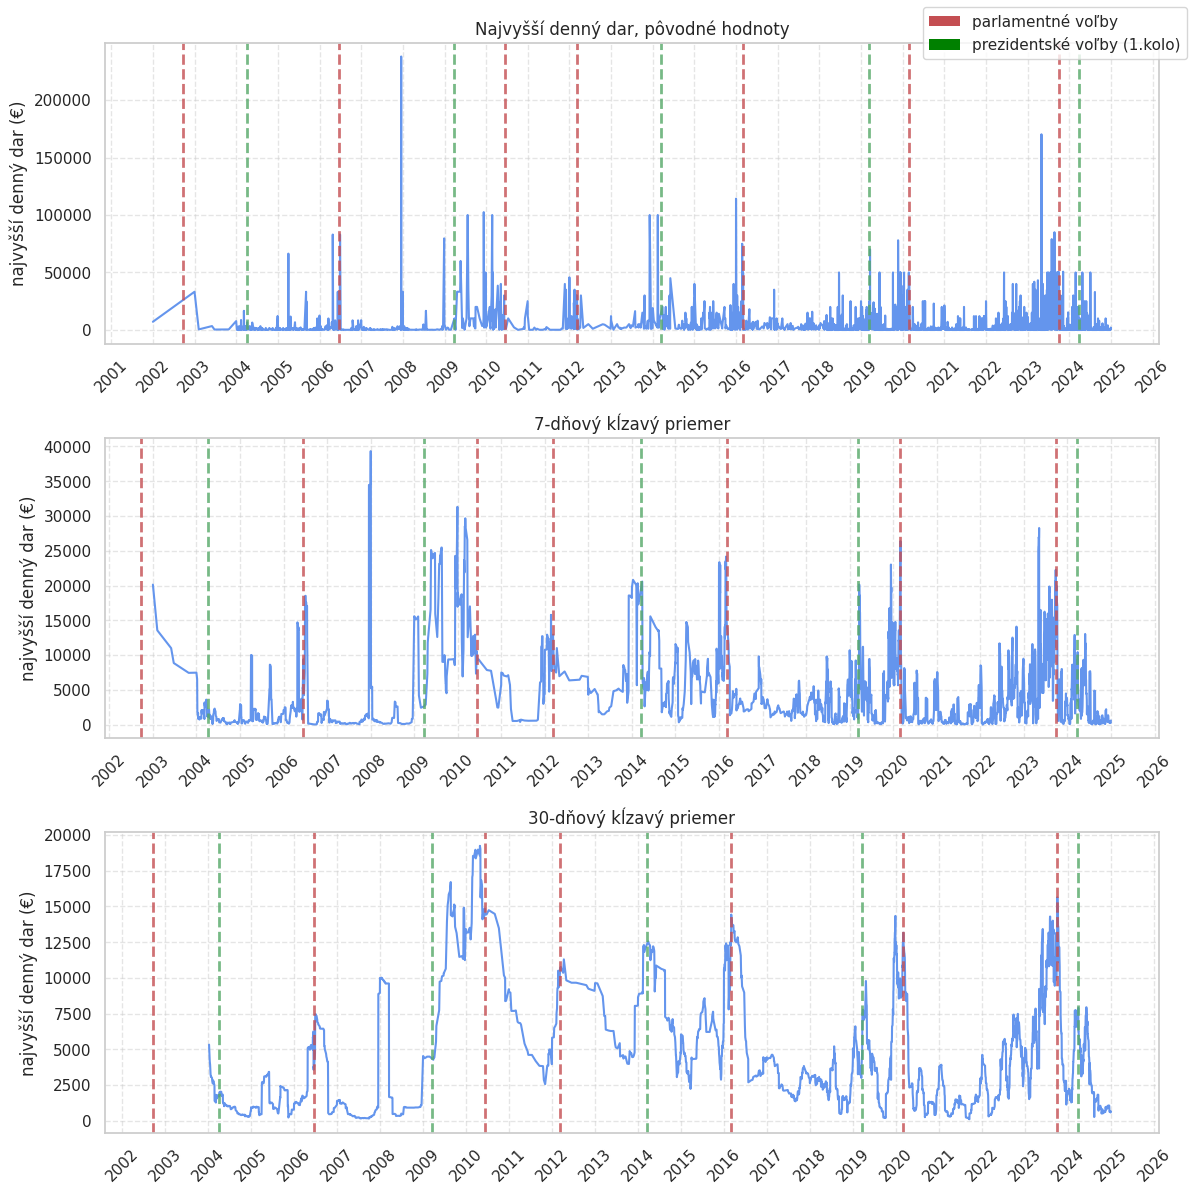

In [13]:
df1 = donations_only.copy()

df1['date'] = pd.to_datetime(df['date'],format='mixed')
df1.sort_values('date', inplace=True)

df2 = df1.groupby("date")["amount"].max()
rolling7 = df2.rolling(7,min_periods=2).mean()
rolling30 = df2.rolling(30,min_periods=10).mean()

fig,ax = plt.subplots(3,1,figsize=(12,12))
sns.lineplot(data=df2,ax=ax[0],color="cornflowerblue")
sns.lineplot(data=rolling7,ax=ax[1],color="cornflowerblue")
sns.lineplot(data=rolling30,ax=ax[2],color="cornflowerblue")

election_years = pd.read_csv("data_sources/election_dates.csv",sep=";")
election_years = election_years.apply(pd.to_datetime,format="%Y-%m-%d")
ax[0].set_title("Najvyšší denný dar, pôvodné hodnoty")
ax[1].set_title("7-dňový kĺzavý priemer")
ax[2].set_title("30-dňový kĺzavý priemer")

import matplotlib.dates as mdates

for i in range(3):
    ax[i].xaxis.set_major_locator(mdates.YearLocator(1)) 
    ax[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    for tick in ax[i].get_xticklabels():
        tick.set_rotation(45)
    ax[i].set_ylabel("najvyšší denný dar (€)")
    ax[i].set_xlabel("")
    ax[i].grid(linestyle="--", alpha=0.5)

#ELECTION YEARS
for i in election_years['parliamentary']:
    for j in range(3):
        ax[j].axvline(i,linewidth=2, color='r',ls='--',alpha=0.8)
for i in election_years["presidential"].dropna():
    for j in range(3):
        ax[j].axvline(i,linewidth=2, color='g',ls='--',alpha=0.8)

topbar = plt.Rectangle((0,0),1,1,fc="r", edgecolor = 'none')
bottombar = plt.Rectangle((0,0),1,1,fc='green',  edgecolor = 'none')
l = fig.legend([topbar,bottombar], ['parlamentné voľby',"prezidentské voľby (1.kolo)"], loc='upper right', prop={'size':11})
l.draw_frame(True)



plt.tight_layout()
plt.savefig(image_folder + "najvyssi_denny_dar.pdf",bbox_inches='tight')
plt.show()
pass



## sucet prispevkov po rokoch

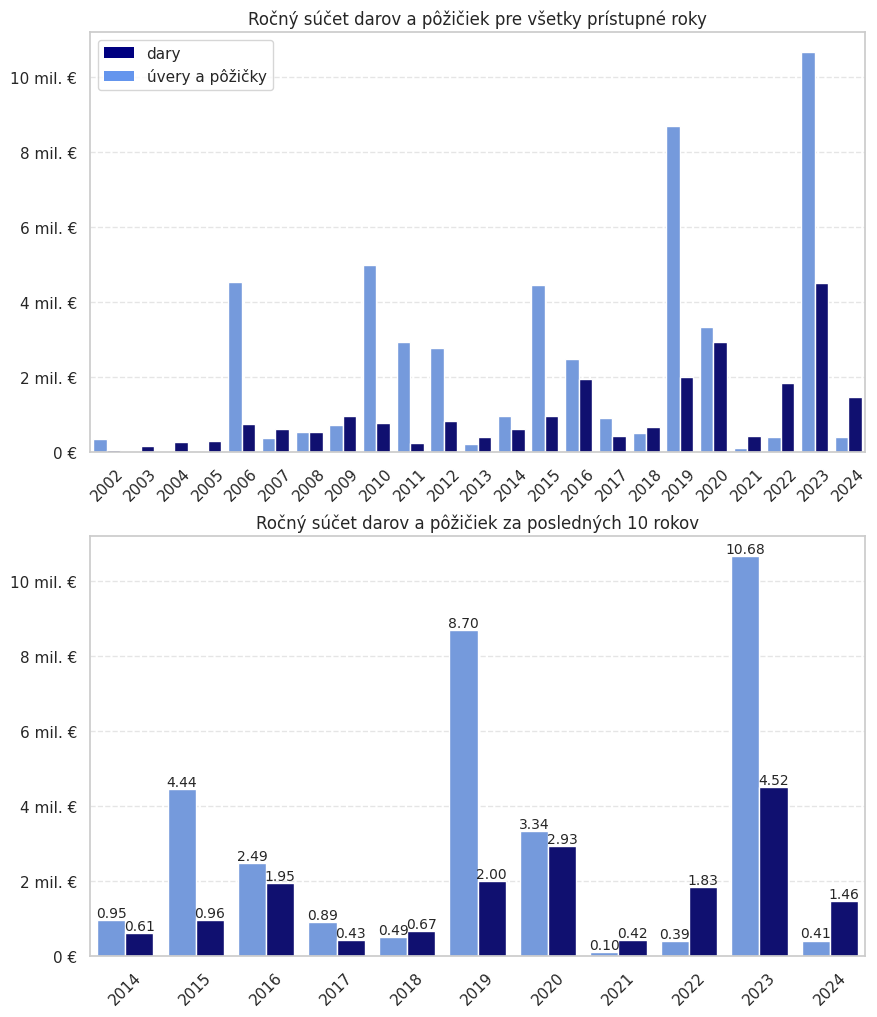

In [14]:
fig,ax = plt.subplots(2,1,figsize=(10,12))
df1 = df.groupby(["year","category"])["amount"].sum().reset_index() 
sns.barplot(data=df1,x="year",y="amount",hue="category",palette=my_palette,alpha=1,ax=ax[0],legend=False)

most_recent_year = max(df["year"])
ten_years_back = most_recent_year - 11


df2 = df.query("year > @ten_years_back")
df2 = df2.groupby(["year","category"])["amount"].sum().reset_index()
sns.barplot(data=df2,x="year",y="amount",hue="category",ax=ax[1],palette=my_palette,alpha=1,legend=False)

# legend_twocolors(2)
topbar = plt.Rectangle((0,0),1,1,fc="navy", edgecolor = 'none')
bottombar = plt.Rectangle((0,0),1,1,fc='cornflowerblue',  edgecolor = 'none')
ax[0].legend([topbar,bottombar], ['dary','úvery a pôžičky'], loc="upper left", ncol = 1, prop={'size':11})

def round_milions(x):
	return f"{x/1_000_000:,.2f}"

for i in range(2):
	ax[1].bar_label(ax[1].containers[i],fontsize=10,fmt=round_milions)


l.draw_frame(True) 

# df1 = df.groupby("year")["amount"].sum().reset_index() 
# sns.barplot(data=df1,x="year",y="amount")
for i in range(2):
	for tick in ax[i].get_xticklabels():
		tick.set_rotation(45)
	ax[i].grid(axis="y",linestyle="--", alpha=0.5)
	ax[i].yaxis.set_major_formatter(ticker.FuncFormatter(million_formatter))
	ax[i].set_ylabel("")
	ax[i].set_xlabel("")
# plt.suptitle("Súkromné peniaze v politike počas rokov")
ax[0].set_title("Ročný súčet darov a pôžičiek pre všetky prístupné roky")
ax[1].set_title("Ročný súčet darov a pôžičiek za posledných 10 rokov")
plt.savefig(image_folder + "sucet_roky.pdf",bbox_inches='tight')

pass

## pocet prispevkov po rokoch

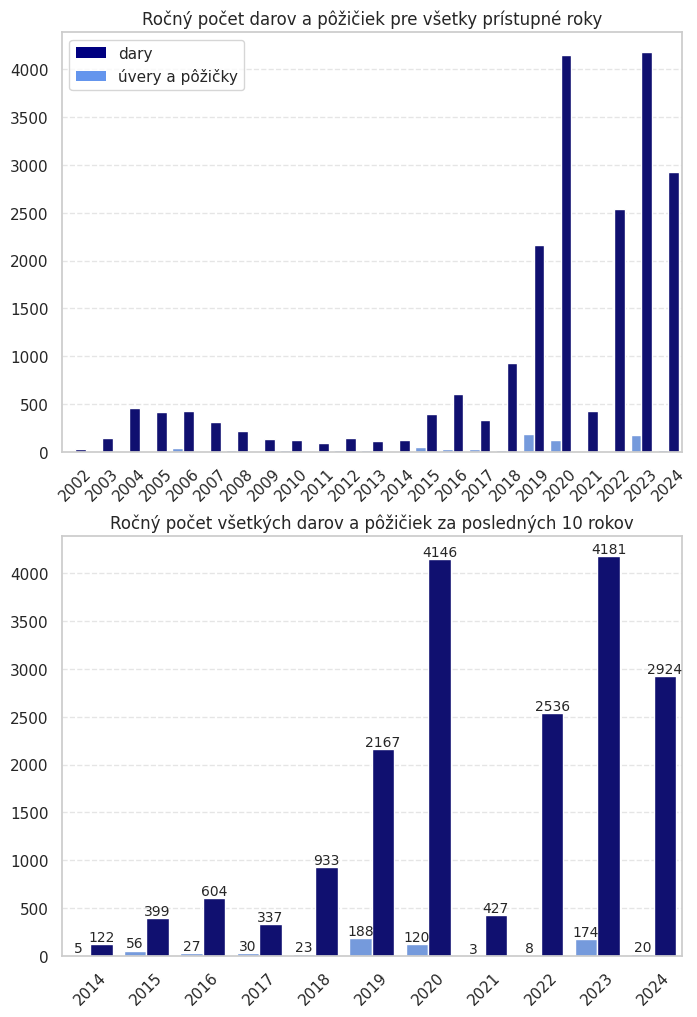

In [15]:
fig,ax = plt.subplots(2,1,figsize=(8,12))
df1 = df.groupby(["year","category"])["amount"].count().reset_index() 
sns.barplot(data=df1,x="year",y="amount",hue="category",palette=my_palette,alpha=1,legend=False,ax=ax[0])


df2 = df.query("year > @ten_years_back")
df2 = df2.groupby(["year","category"])["amount"].count().reset_index()
sns.barplot(data=df2,x="year",y="amount",hue="category",ax=ax[1],palette=my_palette,alpha=1,legend=False)

topbar = plt.Rectangle((0,0),1,1,fc="navy", edgecolor = 'none')
bottombar = plt.Rectangle((0,0),1,1,fc='cornflowerblue',  edgecolor = 'none')
ax[0].legend([topbar,bottombar], ['dary','úvery a pôžičky'], loc="upper left", ncol = 1, prop={'size':11})

for i in range(2):
	ax[1].bar_label(ax[1].containers[i],fontsize=10)

for i in range(2):
	for tick in ax[i].get_xticklabels():
		tick.set_rotation(45)
	ax[i].grid(axis="y",linestyle="--", alpha=0.5)
	ax[i].set_ylabel("")
	ax[i].set_xlabel("")

ax[0].set_title("Ročný počet darov a pôžičiek pre všetky prístupné roky")
ax[1].set_title("Ročný počet všetkých darov a pôžičiek za posledných 10 rokov")
plt.savefig(image_folder + "pocet_roky.pdf",bbox_inches='tight')

pass


top 10 firiem vratane poziciek (bez uverov)

In [16]:
df1 = df.query("income_type != 'úver'& user_type != 'fyzická osoba'")
df1 = df1[~df1["donor"].str.contains("banka|strana", case=False, na=False)]


df2 = df1.groupby(["user_id", "donor"]).agg({
    "amount": "sum",
    "party": lambda x: ", ".join(x.unique()),
    "income_type": lambda x: ", ".join(x.unique())
}).reset_index()

df2 = df2.rename(columns={"amount": "Suma", "party": "Podporené strany", "income_type": "Typ príjmu"})
df2 = df2.sort_values("Suma", ascending=False).head(10)

df_display = df2.drop(columns=["user_id"]).rename(columns={"donor": "Firma"})

display(df_display.style.set_caption("Top 10 firiem").hide().format({"Suma": "{:,.2f}"}))
# print(df_display.style.set_caption("Top 10 firiem").hide().format({"Suma": "{:,.2f}"}).to_latex())


Firma,Suma,Podporené strany,Typ príjmu
"INVOLVE, s.r.o.","2,105,136.00",SDKÚ-DS,pôžička
Bojnická urbárska akciová spoločnosť,"700,000.00",KRESŤANSKÁ ÚNIA,pôžička
"EOSNEBOTRA, a.s.","371,000.00",MODRÍ,pôžička
"Optifin Invest, s.r.o.","360,350.16",ĽS-HZDS,pôžička
"Element Business, s.r.o.","300,000.00",HLAS,pôžička
"FORK, s.r.o.","250,000.00",KRESŤANSKÁ ÚNIA,pôžička
"EPLFINANCE Prešov, s.r.o.","200,000.00",SDKÚ-DS,finančný dar
"LEGAMED, s.r.o.","200,000.00",ZA ĽUDÍ,pôžička
VST Verbundschalungstechnik,"165,970.00",SDKÚ-DS,finančný dar
"LP Promotion, s.r.o.","154,545.97",SIEŤ,bezodplatné plnenie


## top 10 sponzorov vratane poziciek

In [17]:
df1 = df.query("income_type != 'úver' & user_type != 'firma'")


df2 = df1.groupby(["user_id", "donor"]).agg({
    "amount": "sum",
    "party": lambda x: ", ".join(x.unique()),
    "income_type": lambda x: ", ".join(x.unique())
}).reset_index()

df2 = df2.rename(columns={"amount": "Suma príspevkov", "party": "Podporené strany", "income_type": "Typ príjmu"})
df2 = df2.sort_values("Suma príspevkov", ascending=False).head(10)

df_display = df2.drop(columns=["user_id"]).rename(columns={"donor": "Osoba"})

display(df_display.style.set_caption("Top 10 sponzorov a ich strany").hide().format({"Suma príspevkov": "{:,.0f}"}))
# print(df_display.style.set_caption("Top 10 sponzorov a ich strany").hide().format({"Suma príspevkov": "{:,.0f}"}).to_latex())

Osoba,Suma príspevkov,Podporené strany,Typ príjmu
Boris Kollár,"2,137,782",SME RODINA,"pôžička, bezodplatné plnenie"
Andrej Kiska,"1,750,000",ZA ĽUDÍ,pôžička
Peter Zálešák,"1,430,500","PS, ZA ĽUDÍ, TEAM BRATISLAVA","finančný dar, pôžička"
Michal Truban,"1,317,000",PS,"finančný dar, pôžička"
Alojz Hlina,"960,100","KDH, SAS","finančný dar, pôžička, bezodplatné plnenie"
Dezider Németh,"960,000","SMK, SZÖVETSÉG - ALIANCIA",pôžička
Martin Pekár,"795,800","SPOLU, PS","pôžička, finančný dar"
Andrej Danko,"792,822",SNS,"členský príspevok, pôžička, bezodplatné plnenie"
Ivan Štefunko,"661,000",PS,"finančný dar, pôžička"
László Sólymos,"647,400",MOST-HÍD,"finančný dar, členský príspevok, pôžička"


## top 10 darcov (iba dary a clenske)

In [18]:
df1  = donations_only.query("user_type != 'firma'")

df2 = df1.groupby(["user_id", "donor"]).agg({
    "amount": "sum",
    "party": lambda x: ", ".join(x.unique()),
    "income_type": lambda x: ", ".join(x.unique())
}).reset_index()

df2 = df2.rename(columns={"amount": "Suma", "party": "Podporené strany", "income_type": "Typ príjmu"})
df2 = df2.sort_values("Suma", ascending=False).head(10)

df_display = df2.drop(columns=["user_id"]).rename(columns={"donor": "Osoba"})

display(df_display.style.set_caption("Top 10 sponzorov a ich strany").hide().format({"Suma": "{:,.0f}"}))
# print(df_display.style.set_caption("Top 10 sponzorov a ich strany").hide().format({"Suma": "{:,.0f}"}).to_latex())


Osoba,Suma,Podporené strany,Typ príjmu
Miroslav Suja,"305,713","ĽSNS, REPUBLIKA","bezodplatné plnenie, finančný dar, členský príspevok, nepeňažný dar"
Ján Šubák,"299,258",DEMOKRATI,"nepeňažný dar, finančný dar"
Rudolf Trávniček,"237,970",ĽS-HZDS,finančný dar
László Sólymos,"229,600",MOST-HÍD,"finančný dar, členský príspevok"
Anna Záborská,"213,841","KDH, KRESŤANSKÁ ÚNIA","finančný dar, bezodplatné plnenie, členský príspevok"
Elemér Jakab,"177,600",MOST-HÍD,"finančný dar, členský príspevok"
Miloš Jaroška,"165,000","SPOLU, PS",finančný dar
Ivan Štefanec,"164,300","SDKÚ-DS, KDH","členský príspevok, finančný dar"
Zsolt Simon,"158,400","MOST-HÍD, MAĎARSKÉ FÓRUM, ODS, ZA REGIÓNY, RÓMSKA KOALÍCIA, DS, FÓRUM","finančný dar, členský príspevok"
Juraj Miškov,"155,200",SAS,"finančný dar, členský príspevok"
